## **Describing a Single Set of Data**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from typing import List

In [2]:
# num_friends = [
#     6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 
#     12, 12, 13, 13, 14, 14, 15, 15, 16, 17, 18, 18, 19, 20, 21, 22, 
#     23, 24, 25, 26, 27, 28, 30, 31, 33, 34, 36, 37, 39, 41, 42, 44, 
#     46, 48, 50, 52, 54, 56, 59, 61, 63, 66, 68, 71, 73, 76, 79, 81, 
#     84, 87, 89, 92, 95, 98, 100, 100, 99, 97, 96, 94, 93, 91, 89, 88, 
#     86, 85, 83, 82, 80, 78, 77, 75, 74, 72, 71, 70, 69, 68, 67, 66
# ]



num_friends = [
    19, 90, 56, 39, 8, 8, 6, 76, 39, 53, 6, 94, 71, 10, 9, 9, 14, 31, 23, 13, 
    41, 7, 14, 18, 25, 63, 9, 30, 38, 6, 40, 8, 6, 90, 93, 67, 14, 6, 50, 24, 
    7, 29, 6, 83, 12, 47, 15, 31, 34, 9, 94, 62, 88, 81, 39, 85, 6, 9, 6, 15, 
    20, 12, 70, 17, 13, 33, 7, 66, 6, 97, 62, 9, 6, 68, 52, 55, 61, 6, 18, 7, 
    76, 42, 16, 6, 15, 15, 56, 44, 79, 26, 7, 53, 60, 35, 61, 28, 31, 23, 6, 7, 
    6, 44, 15, 30, 83, 11, 21, 59, 10, 6, 13, 8, 87, 67, 43, 77, 66, 9, 80, 33, 
    67, 81, 15, 7, 10, 23, 68, 75, 6, 30, 22, 10, 7, 16, 89, 15, 31, 52, 18, 94, 
    93, 11, 29, 14, 13, 6, 40, 29, 6, 13, 83, 11, 7, 28, 97, 11, 48, 60, 11, 55, 
    18, 43, 43, 32, 6, 71, 15, 9, 6, 38, 49, 6, 30, 10, 45, 8, 50, 20, 88, 7, 
    16, 7, 86, 78, 12, 46, 68, 34, 32, 11, 6, 81, 82, 43, 16, 17, 55, 81, 79, 63
]

label = [i for i in range(len(num_friends))]

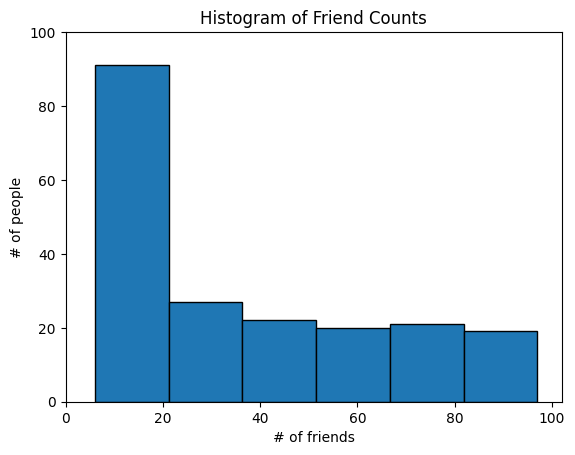

In [3]:
plt.hist(num_friends, bins='fd', edgecolor='black')
plt.axis([0, max(num_friends)+5, 0, 100])
plt.title("Histogram of Friend Counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")

plt.show()

In [4]:
num_point = len(num_friends) # shape of data

num_point

200

In [5]:
largest_value = max(num_friends)
smallest_value = min(num_friends)

largest_value, smallest_value 

(97, 6)

### **Central Tendencies**

In data science, **central tendency** refers to a single value that attempts to describe a set of data by identifying the central position within that dataset. These are the "summary statistics" you use to understand the "typical" or "middle" behavior of your data before performing deeper analysis.

- **The Big Three**

| Measure | What it represents | Best Use Case |
| :--- | :--- | :--- |
| **Mean** | The arithmetic average (the "balance point"). | Symmetrical numerical data without outliers. |
| **Median** | The middle value (the 50th percentile). | Skewed data (e.g., income, house prices). |
| **Mode** | The most frequent value. | Categorical data or discrete frequency analysis. |

---

- **Why this matters for Data Science**
    - In the context of your data analysis and machine learning workflow:
        * **Exploratory Data Analysis (EDA):** You use these measures to get an immediate snapshot of your features. If the mean and median are significantly different, you know immediately that your data is skewed.
        * **Data Cleaning & Imputation:** You use the **median** to fill missing values if your data has outliers, as the mean would be pulled toward the extremes, giving you a distorted "average."
        * **Feature Engineering:** Understanding the central tendency is the first step before you perform normalization or standardization (like Z-score scaling), which rely on the mean.

- **Beyond the Basics: Quantiles**
    - While Mean, Median, and Mode provide a single point of reference, **Quantiles** (like quartiles or percentiles) allow you to understand the **spread** of your data.

* **Interquartile Range (IQR):** By calculating the 25th ($Q1$) and 75th ($Q3$) percentiles, you define the "middle 50%" of your data. This is the standard data science approach for identifying outliers (any data point $> Q3 + 1.5 \times \text{IQR}$ is typically flagged).

#### **Mean**

The **mean** (often called the arithmetic average) is the most commonly used measure of central tendency. It is essentially the "balance point" of your dataset.

- **What is the Mean?**
    - The mean is calculated by summing all the values in a dataset and dividing that total by the number of observations ($n$).

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

---

- **Why Data Scientists Use the Mean**
    - The mean is mathematically elegant and central to the majority of classical statistical techniques.

* **Representativeness:** If your data is "normally distributed" (the bell curve), the mean is the most accurate representation of the "typical" value.
* **Mathematical Foundation:** Most machine learning algorithms (like Linear Regression) are designed to minimize the sum of squared differences from the mean.
* **Aggregations:** In data analysis, the mean is the primary way to aggregate metrics for business reporting (e.g., "What was the average revenue per user last quarter?").

---

- **The "Achilles' Heel" of the Mean: Outliers**
    - As a data science student, you must always be cautious. The mean is **highly sensitive to extreme values (outliers)**. 

- Imagine you have a group of 5 people with these annual incomes:
    - `$50k, $55k, $60k, $65k, $70k` $\rightarrow$ **Mean: $60k**

- Now, imagine a billionaire walks into the room:
    - `$50k, $55k, $60k, $65k, $70k, $1,000,000,000` $\rightarrow$ **Mean: ~$166.7 Million**

The mean is no longer "typical" or "representative" of anyone in that room. This is why data scientists always check the **median** alongside the mean; if they differ significantly, your data is likely skewed.

---

- **Best Practices for Your EDA**
1.  **Check for Skewness:** If `mean > median`, your data is likely "right-skewed" (a long tail of high values). If `mean < median`, it is "left-skewed."
2.  **Imputation:** When filling in missing data in your datasets, using the mean is quick, but it can artificially reduce the variance of your data. Consider if the median or a grouped-mean might be more appropriate.
3.  **Visualization:** Always plot a histogram. Seeing the mean in relation to the distribution curve is the fastest way to understand your data's "shape."

In [8]:
def mean(xs: List[float]) -> float:
    """Calculate the arithmetic average"""
    return sum(xs) / len(xs)

In [9]:
mean(num_friends)

35.64

#### **Median**

The **median** is the "middle" value of a dataset. While the mean represents the balance point, the median represents the **50th percentile**—the exact point that splits your data into two equal halves.

- **How to Find the Median**
1.  **Sort:** Arrange your data in ascending order.
2.  **Locate:**
    * If you have an **odd** number of data points, the median is the single middle value.
    * If you have an **even** number of data points, the median is the **mean of the two middle values**.

---

- **Why Data Scientists Prefer the Median**
    - In real-world data, the median is often more **robust** than the mean. 

* **Resistance to Outliers:** Unlike the mean, the median is not "pulled" by extreme values. If you have 1,000 users and one of them is a billionaire, the mean income will skyrocket, but the median income will barely move. 
* **Skewed Data:** When you analyze skewed distributions (like income, website dwell time, or house prices), the median is a far more accurate "typical" value.

---

- **Median vs. Mean: The "Skew" Test**
    - As a data science student, comparing these two is one of your fastest ways to perform a quality check during **Exploratory Data Analysis (EDA)**:

| Distribution Type | Relationship |
| :--- | :--- |
| **Symmetric (Normal)** | Mean $\approx$ Median |
| **Right-Skewed (Positive)** | Mean $>$ Median |
| **Left-Skewed (Negative)** | Mean $<$ Median |

---

- **Python Implementation**
    - In your Jupyter notebooks, calculating this is trivial:

```python
import numpy as np

data = [10, 20, 30, 40, 1000] # 1000 is an outlier

# Mean: (1100 / 5) = 220
# Median: 30
mean_val = np.mean(data)
median_val = np.median(data)

print(f"Mean: {mean_val}")
print(f"Median: {median_val}") # 30 is much more representative!
```

In [10]:
def _median_odd(xs: List[float]) -> float:
    """If len(xs) is odd, the median is the middle element"""
    
    return sorted(xs)[len(xs) // 2]

In [11]:
def _median_even(xs: List[float]) -> float:
    """If len(xs) is even, it's the average of the middle two elements"""
    index = len(xs) // 2
    
    return (sorted(xs)[index] + sorted(xs)[index-1]) / 2

In [12]:
def median(xs: List[float]) -> float:
    """Finds the 'middle-most' value of v"""
    
    return _median_odd(xs) if len(xs) % 2 != 0 else _median_even(xs)

In [13]:
median(num_friends)

28.5

In [14]:
median([1, 10, 2, 9, 5]), median([1, 9, 2, 10])

(5, 5.5)

> There are, in fact, nonobvious tricks to efficiently [**compute medians**](https://en.wikipedia.org/wiki/Quickselect) without sorting the data. However, they are beyond the scope of this book, so we have to sort the data.

#### **Quantile**

A **quantile** is a statistical tool used to divide a distribution of data into equal-sized subgroups. If you think of your data as a single long line, quantiles are the "markers" you place at specific intervals to slice that line into segments.

- **Why Data Scientists Use Quantiles**
    - While measures like the mean and median tell you about the "center," quantiles tell you about the **entire shape and spread of the data**. They are essential for:
        * **Outlier Detection:** Quantiles allow you to define what is "normal" and what is "extreme." 
        * **Data Normalization:** In many machine learning workflows, you use quantile-based scaling to handle skewed data that doesn't follow a normal distribution.
        * **Performance Analysis:** Instead of looking at an average, you might look at the 95th or 99th percentile of response times to understand the experience of your "worst-case" users.

---

- **Common Types of Quantiles**
    - You have likely heard of the most popular specific types of quantiles:

| Name | Number of Divisions | Description |
| :--- | :--- | :--- |
| **Quartiles** | 4 | Divides data into 4 equal parts (25%, 50%, 75%). |
| **Deciles** | 10 | Divides data into 10 equal parts (each 10%). |
| **Percentiles** | 100 | Divides data into 100 equal parts (each 1%). |

![Image of a box plot showing quartiles and median](../Images/Quantile.jpeg)

---

- **The Power of the Interquartile Range (IQR)**
    - As you have been exploring statistics, the most practical use of quantiles is the **IQR**. It is calculated as:
**$$\text{IQR} = Q3 - Q1$$**
*(Where $Q3$ is the 75th percentile and $Q1$ is the 25th percentile).*

Because the IQR only looks at the "middle 50%" of your data, it is **robust**. It completely ignores the outliers in the bottom 25% and top 25%, giving you a clean measure of where the core of your data sits.

---

- **Python Implementation**
    - In your Data Science projects, `pandas` makes calculating these trivial:

```python
import pandas as pd

data = [10, 15, 20, 25, 30, 35, 40, 100] # 100 is an outlier
series = pd.Series(data)

# Calculate quartiles
q1 = series.quantile(0.25)
q3 = series.quantile(0.75)
iqr = q3 - q1

print(f"Q1: {q1}, Q3: {q3}")
print(f"IQR: {iqr}")
```

In [15]:
def quantile(xs: List[float], i: float) -> float:
    """Returns the pth-percentile value in x"""
    
    p_index= int(len(xs) * i)
    return sorted(xs)[p_index]

In [19]:
quantile(num_friends, 0.25), quantile(num_friends, 0.50), quantile(num_friends, 0.75)

(10, 29, 60)

In [20]:
median(num_friends)

28.5

#### **Mode**

The **mode** is the final member of the central tendency trio. While the mean focuses on the "average" and the median focuses on the "middle," the **mode** focuses on **frequency**.

- **What is the Mode?**
    - The mode is simply the value that appears **most frequently** in a dataset.

* **Unimodal:** A dataset with one clear, most frequent value.
* **Bimodal/Multimodal:** A dataset where two or more values appear with the same maximum frequency.
* **No Mode:** If every value appears only once, the dataset technically has no mode.

---

- **Why Data Scientists Use the Mode**
    - Unlike the mean and median, which are purely numerical, the mode is the **only measure of central tendency that works for categorical (nominal) data.**

* **Categorical Insight:** If you are analyzing a column in your dataset like `User_Country`, `Product_Category`, or `Color`, you cannot calculate a mean or a median. The mode tells you the most popular category, which is vital for business intelligence and feature engineering.
* **Data Profiling:** In your EDA process, calculating the mode is an excellent way to identify the "typical" behavior. If you are processing server logs and the mode of `Status_Code` is `200`, your system is healthy. If the mode suddenly shifts to `500`, you have an immediate data quality or system alert.

---

- **Comparison Summary**

| Tendency | Focus | Best For |
| :--- | :--- | :--- |
| **Mean** | The balance point | Symmetric numerical data |
| **Median** | The physical center | Skewed numerical data |
| **Mode** | The most frequent occurrence | Categorical or discrete data |

---

- **Python Implementation**
    - In your Data Science workflows, using `collections.Counter` or `pandas.Series.mode()` is the standard, high-performance way to find the mode.

```python
from collections import Counter

# Categorical data example
categories = ['Red', 'Blue', 'Red', 'Green', 'Blue', 'Red']

# Get the most common value
mode_data = Counter(categories).most_common(1)
print(f"The mode is: {mode_data[0][0]}") # Result: 'Red'
```

In [23]:
from collections import Counter

In [38]:
def mode(xs: List[float]) -> List[int]:
    """Returns a list, since there might be more than one mode"""
    
    friend_counter = Counter(xs)
    
    return friend_counter.most_common(1)[0][0]
    


In [39]:
mode(num_friends)

6

### **Dispersion**

In data science, **dispersion measures** (or measures of variability) quantify how "spread out" or clustered your data points are. While measures of central tendency (mean, median, mode) tell you where the "center" of your data is, dispersion measures describe the **reliability** and **consistency** of that center.


- **Why Dispersion Matters**
    - If you are building a machine learning model, dispersion is critical:
        * **Predictability:** A dataset with low dispersion around the mean is more predictable. A high dispersion often implies higher noise or underlying volatility.
        * **Outlier Detection:** Dispersion measures are the primary way to identify statistical anomalies.
        * **Feature Scaling:** Many algorithms (like SVMs or K-Means) require features to be scaled based on their dispersion (Standard Deviation) so that one feature doesn't dominate the others just because of its larger range.

---

- **The Primary Measures of Dispersion**

| Measure | Definition | Best For |
| :--- | :--- | :--- |
| **Range** | Difference between max and min values. | Initial "sanity check" for bounds. |
| **Variance** | Average of squared differences from the mean. | Foundational math for predictive modeling. |
| **Standard Deviation** | Square root of the variance. | Interpretable "typical" spread in original units. |
| **Interquartile Range (IQR)** | Distance between the 75th and 25th percentiles. | Robust analysis of skewed data or outliers. |

---

- **Understanding the Trade-offs**

- **1. Range (The Simple View)**
    - The range gives you the total span of your data. However, it is **highly sensitive to outliers**. If your dataset is 99% values between 10 and 20, but one value is 500, the range will tell you the data is "spread out" across 490 units, which is misleading.

- **2. Variance & Standard Deviation (The Statistical View)**
    - These measure how much, on average, each point deviates from the mean.
        * **Variance ($\sigma^2$)** is mathematically convenient for formulas but uses squared units (e.g., dollars squared).
        * **Standard Deviation ($\sigma$)** is the most popular because it brings the scale back to the original units (e.g., dollars), making it easier to explain to stakeholders.

- **3. Interquartile Range - IQR (The Robust View)**
    - When you have heavily skewed data (like income or website traffic), the **IQR** is your best friend. It focuses on the "middle 50%" of your data, completely ignoring the extremes.

---

- **Practical Application for Data Science Students**
    - When you are performing Exploratory Data Analysis (EDA) on a new dataset, you should always look at these together:
        1.  **Check the Range:** Do the min/max values make sense? (Data cleaning step).
        2.  **Compare Mean vs. Median:** Are they close? If not, use **IQR** for spread.
        3.  **Use Standard Deviation:** If the data is normally distributed, use this to determine what counts as an "unusual" value (Z-score).

#### **Range**

The **range** is the simplest and most intuitive measure of dispersion. It represents the total span of your data by calculating the difference between the maximum and minimum values in a dataset.

- **The Formula**
$$\text{Range} = \text{Maximum Value} - \text{Minimum Value}$$

---

- **Why Data Scientists Use It**
    - While it is the crudest measure of dispersion, it serves specific purposes in your data science workflow:
        * **Quick Health Check:** In your initial **Exploratory Data Analysis (EDA)**, you can use the range to perform "sanity checks." If you are analyzing a dataset that should logically fall between 0 and 100, a range calculation will immediately tell you if your data contains impossible values that need cleaning.
        * **Defining Boundaries:** The range helps you understand the absolute limits of your data. If your range is unexpectedly large, it indicates the presence of extreme outliers that might significantly bias your mean or distort your predictive models.

---

- **The Limitation: Sensitivity**
    - The range is **extremely sensitive to outliers**. If you have a dataset of 1,000 values all clustered between 10 and 20, but one single value is 500, your range is $500 - 10 = 490$. This makes the range suggest a massive spread, even though 99.9% of your data is very tightly packed.

Because of this, data scientists rarely use the range as their *only* measure of dispersion. They almost always pair it with more robust metrics:

| Metric | Sensitivity to Outliers | Use Case |
| :--- | :--- | :--- |
| **Range** | Extremely High | Rough sanity checks, boundary validation |
| **IQR (Interquartile Range)** | Low | Understanding spread of the "core" data |
| **Standard Deviation** | Moderate | Statistical modeling and anomaly detection |

---

- **Python Implementation**
    - In your own data analysis scripts, implementing this is straightforward:

```python
data = [10, 15, 12, 18, 100] # 100 is an outlier

# Calculate range
data_range = max(data) - min(data)

print(f"The range is: {data_range}") # Result: 90
```

In [41]:
def data_range(xs: List[float]) -> float:
    """calculate the range of data"""
    
    return max(xs) - min(xs)

In [42]:
data_range(num_friends)

91

#### **Variance**

**Variance** is the average of the squared differences between each data point and the mean. While the range tells you the total distance between the extremes, variance tells you how "spread out" the *entire* dataset is relative to its center (**`mean`**).

- **The Mathematical Intuition**
    - To calculate variance ($\sigma^2$), you follow these steps:
        1.  Find the mean ($\bar{x}$).
        2.  Subtract the mean from every individual value and square the result (this ensures all differences are positive and emphasizes larger outliers).
        3.  Average those squared differences.

---

- **Why Variance Matters for Data Science**
    - Variance is much more than a descriptive statistic; it is a **foundational building block** for predictive modeling:
        * **Measuring Uncertainty:** High variance means your data is volatile and unpredictable. Low variance means your data is stable and consistent.
        * **Feature Selection:** In Machine Learning, if a feature has zero or very low variance (e.g., a column where 99% of values are the same), it contains almost no useful information. Data scientists often drop these "low-variance" features to reduce noise.
        * **Optimization:** Many algorithms work by trying to **minimize variance** (the error) in predictions. For example, in regression, you are effectively trying to find a line that minimizes the variance of the residuals (the differences between predicted and actual values).

---

- **Variance vs. Standard Deviation**
    - You will notice that variance is always in "squared" units (e.g., if your data is in dollars, variance is in dollars-squared). This makes it hard to interpret directly.

* **Standard Deviation ($\sigma$):** Is simply the square root of the variance ($\sqrt{\sigma^2}$). It brings the measurement back to the original units of your data, making it much more interpretable for reporting to stakeholders.

---

- **Python Implementation**
    - Since you are a Data Science student, you will likely use `numpy` to calculate this efficiently, as it is highly optimized for vector operations:

```python
import numpy as np

# Sample data
data = [10, 20, 30, 40, 50]

# Calculate variance (ddof=1 for sample variance)
variance = np.var(data, ddof=1)

# Calculate standard deviation
std_dev = np.std(data, ddof=1)

print(f"Variance: {variance}") # 250.0
print(f"Standard Deviation: {std_dev}") # 15.81
```

The mathematical "rule" for variance depends on whether you are analyzing a complete **Population** or a **Sample** (which is a subset used to estimate the population).

- **1. The Population Variance ($\sigma^2$)**
    - When you have the data for every single member of a group, you use the population variance. It is the average of the squared deviations from the population mean ($\mu$).

$$\sigma^2 = \frac{\sum_{i=1}^{n} (x_i - \mu)^2}{n}$$

* **$x_i$:** Each individual value.
* **$\mu$:** The mean of the entire population.
* **$n$:** The total number of items in the population.

---

- **2. The Sample Variance ($s^2$)**
    - When you have a sample, the "rule" changes to correct for bias. As we discussed, because you are using a sample mean ($\bar{x}$) as an estimate, the result would be artificially small if you divided by $n$. To fix this, you divide by **$n - 1$** (Bessel's Correction).

$$s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$$

* **$\bar{x}$:** The mean of the sample.
* **$n - 1$:** The degrees of freedom.

---

- **3. The "Shortcut" Computational Formula**
    - In data science and programming, you rarely calculate variance by iterating through every point and subtracting the mean manually (it is computationally expensive). Instead, you use the algebraic expansion of the variance formula:

$$s^2 = \frac{\sum x_i^2 - \frac{(\sum x_i)^2}{n}}{n - 1}$$

- **Why use this?**
    * **Efficiency:** You only need two passes (or even one pass) through the data: the sum of the values ($\sum x_i$) and the sum of the squares ($\sum x_i^2$). 
    * **Performance:** This is how optimized libraries like `NumPy` often handle large-scale vector calculations.

---

- **Important Mathematical Properties**
    - When working with variance, these rules often come in handy during feature engineering or algorithm derivation:
        * **Non-negativity:** Variance is always $\ge 0$ because all squared deviations are positive.
        * **Linear Transformation Rule:** If you multiply every data point by a constant $a$, the new variance is $a^2$ times the original variance:
            $$\text{Var}(aX) = a^2 \text{Var}(X)$$
        * **Addition Rule:** If you add a constant $b$ to every data point, the variance **does not change**:
            $$\text{Var}(X + b) = \text{Var}(X)$$
            *(Shifting the data doesn't change how spread out it is, only where it is located).*

In [53]:
import math

In [54]:
def variance(xs: List[float]) -> float:
    """Almost the average squared deviation from the mean"""
    x = mean(xs)

    return sum([ math.pow(xs_i - x, 2) for xs_i in xs]) / len(xs)

In [55]:
variance(num_friends)

798.9703999999997

In [56]:
def variance_v1(xs: List[float]) -> float:
    """Almost the average squared deviation from the mean"""

    sum_square_root_xs = sum([math.pow(xs_i, 2) for xs_i in xs])
    mean_squre_root = math.pow(sum(xs), 2) / len(xs)

    return (sum_square_root_xs - mean_squre_root) / len(xs)


In [57]:
variance_v1(num_friends)

798.9703999999999

This is one of the most famous "Aha!" moments in statistics. It centers on the difference between describing a dataset you fully possess (a population) and estimating truths about a dataset you only partially see (a sample).

- **The Core Problem: The "Underestimate" Bias**
    - When you calculate variance using the entire population, you divide by $n$. This gives you the *exact* variance of that set.

However, in Data Science, we rarely have the whole population. We have a **sample**.

1.  **The "Fixed" Mean:** When you calculate the sample mean ($\bar{x}$), it is calculated *using* your specific sample data. Because $\bar{x}$ is perfectly centered to minimize the distance to those specific points, it is naturally closer to them than the true (unknown) population mean would be.
2.  **The Resulting Shrinkage:** Because your sample mean is "chasing" your sample points, the squared distances $(x_i - \bar{x})^2$ are, on average, smaller than the true distances would be against the actual population mean.
3.  **The Correction:** If you divided by $n$, you would consistently calculate a variance that is too small (a "biased" estimator). By dividing by **$n - 1$** (a technique known as **Bessel’s Correction**), you make the denominator smaller, which makes the final result slightly larger. This effectively compensates for the bias and gives you an **unbiased estimate** of the population variance.

---

- **Why $n-1$? (Degrees of Freedom)**
    - Think of this as "Degrees of Freedom." 
        * If you have $n$ data points, you have $n$ independent pieces of information.
        * However, to calculate the variance, you *must* first calculate the mean ($\bar{x}$). Once you have the mean, the final data point in your set is no longer "free" to be any value—it is locked in by the requirement that the set must sum to $n \times \bar{x}$.
        * Because one "degree of freedom" was used up to calculate the mean, you are left with $n - 1$ independent pieces of information to estimate the variance.

---

- **The "Data Science Student" Rule of Thumb**
    - As you move forward in your studies, you will encounter this constantly in libraries like `NumPy` and `Pandas`.

* **Use $n$ (Population Variance):** When you only care about describing the exact data you have in front of you (e.g., "What was the variance of the grades in *this specific class*?").
* **Use $n-1$ (Sample Variance):** When you are using your data to make inferences or predictions about a larger world (e.g., "What is the variance of student grades *in the entire university* based on this class?").

**In your code:**
* `numpy.var(data)` defaults to $n$ (biased).
* `numpy.var(data, ddof=1)` uses $n-1$ (unbiased).

#### **Standard Diviation**

**Standard deviation** ($\sigma$) is the most widely used measure of dispersion in data science. While variance gives you a "squared" value that is hard to interpret, standard deviation brings that dispersion back to the **original units of your data**.

- **What It Tells You**
    - Standard deviation tells you, on average, how much your data points deviate from the mean. 
        * **Low Standard Deviation:** Your data points are clustered very close to the mean (the distribution is "tight" or "peaky").
        * **High Standard Deviation:** Your data points are spread out far from the mean (the distribution is "flat" or "wide").

---

- **The Mathematical Link**
    - It is simply the square root of the variance. Because variance squares the differences between data points and the mean, standard deviation "undoes" that squaring to return to a readable, linear scale.

$$\sigma = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$$

---

- **Why It Is Essential for Data Scientists**

1.  **The Empirical Rule (68-95-99.7):** For a normal distribution, standard deviation allows you to predict where your data lies:
    * **68%** of your data falls within **1** standard deviation of the mean.
    * **95%** falls within **2** standard deviations.
    * **99.7%** falls within **3** standard deviations.
    * *This is a huge shortcut for identifying outliers: any point beyond 3 standard deviations is statistically "rare."*

2.  **Standardization (Z-Score):** You will use standard deviation to "scale" your data. By subtracting the mean and dividing by the standard deviation, you create **Z-scores**. This puts different features (like "Age" and "Income") on the same scale, which is a mandatory step before training many machine learning models.

3.  **Risk Measurement:** In finance and predictive modeling, the standard deviation is the go-to metric for **volatility**. If you are building a model to predict house prices, a high standard deviation in your target variable indicates that your model will inherently have a higher margin of error.

---

- **When to use which?**

| If your data is... | Use this... | Why? |
| :--- | :--- | :--- |
| **Normal (Symmetric)** | **Mean & Standard Deviation** | They perfectly capture the center and spread. |
| **Skewed/Outliers** | **Median & IQR** | Standard deviation is distorted by extreme values. |

In [58]:
def standard_deviation(xs: List[float]) -> float:
    """The standard deviation is the square root of the variance"""

    return math.sqrt(variance(xs))

In [59]:
standard_deviation(num_friends)

28.266064458993927

This passage highlights a fundamental challenge in data science: **sensitivity to extremes**. When you are analyzing data to understand the "typical" behavior of a group (like the number of friends a user has), a few extreme cases can completely distort your statistical results.

- **The Problem: Sensitivity to Outliers**
    - The **range** and **standard deviation** are both "global" measures, meaning they incorporate every single data point in the set.

* **The Mechanism:** Because both metrics use the maximum or minimum values (Range) or the squared distance from the mean (Standard Deviation), a single outlier acts like a heavy weight on a scale—it pulls the entire result toward itself.
* **The Distortion:** As the passage notes, changing just *one* user from having a "normal" amount of friends to having 200 friends inflates the standard deviation by over 60%. This makes the statistic unreliable for describing the "typical" experience of your users.

---

- **The Solution: Robust Statistics**
    - To solve this, we look for **robust** measures—statistics that are resistant to outliers. The passage suggests the **Interquartile Range (IQR)**.

* **The Concept:** Instead of looking at the full range (which is defined by the absolute min/max), the IQR looks at the **middle 50%** of the data. 
* **The Calculation:** It calculates the difference between the 75th percentile ($Q3$) and the 25th percentile ($Q1$).
    * $Q3$ is the point where 75% of data falls below it.
    * $Q1$ is the point where 25% of data falls below it.


![Image of a box plot diagram showing IQR range](../Images/Quantile.jpeg)


- **Why this is better for Data Science**
    - Think of the difference this way:

| Metric | Perspective | Impact of an Outlier |
| :--- | :--- | :--- |
| **Standard Deviation** | "How far is *everyone* from the average?" | High (Every point influences the result) |
| **IQR** | "How spread out is the *main group*?" | Zero (Extreme values outside the 25th-75th range are ignored) |

**In short:** When your data contains outliers (which it almost always does in the real world), the IQR tells you how the *typical* majority of your data behaves, while the standard deviation tells you how *everything*—including the "weird" anomalies—behaves.

In [60]:
def quantile(xs: List[float], p: float) -> float:
    """Returns the pth-percentile value in x"""

    return sorted(xs)[int(len(xs) * p)]

def interquartile_range(xs: List[float]) -> float:
    """Returns the difference between the 75%-ile and the 25%-ile"""
    
    return quantile(xs, 0.75) - quantile(xs, 0.25)

In [61]:
interquartile_range(num_friends)

50

## **Correlation**

**Correlation** is a statistical measure that describes the size and direction of a relationship between two or more variables. It answers the question: *When one variable changes, does the other variable tend to change as well?*

- **The Main Types of Correlation**


![Image of scatter plots showing positive, negative, and no correlation](../Images/correlation.jpeg)


1.  **Positive Correlation:** Both variables move in the same direction. As $X$ increases, $Y$ increases (e.g., hours studied vs. exam scores).
2.  **Negative Correlation:** The variables move in opposite directions. As $X$ increases, $Y$ decreases (e.g., speed of a car vs. time to reach the destination).
3.  **No Correlation:** There is no discernible pattern between the variables; they are independent of each other (e.g., shoe size vs. intelligence).

---

- **The Correlation Coefficient ($r$)**
    - The strength and direction are quantified by the **Pearson Correlation Coefficient**, denoted as $r$. Its value always falls between $-1$ and $+1$:
        * **$r = +1$**: A perfect positive linear relationship.
        * **$r = 0$**: No linear relationship.
        * **$r = -1$**: A perfect negative linear relationship.

- **Correlation vs. Causation: The "Golden Rule"**
    - As a data science student, this is the most critical concept to internalize: **Correlation does not imply causation.**

Just because two variables are correlated doesn't mean one *causes* the other. There is often a "confounding variable" at play.
* **Example:** Ice cream sales and forest fires are positively correlated. Does ice cream cause fires? No. The confounding variable is *hot weather*, which causes both more ice cream sales and more forest fires.

---

- **Why Data Scientists Use Correlation**
    1.  **Feature Selection:** Before training a model, you use a **Correlation Matrix** (often visualized as a heatmap) to see which features are highly correlated with your target variable.
    2.  **Multicollinearity Detection:** If two input features are highly correlated with *each other* (e.g., $r > 0.9$), your model might become unstable. You would typically drop one of them to simplify the model.
    3.  **Data Exploration:** It is one of the first steps in EDA to uncover hidden relationships between variables before you start coding complex algorithms.

- **Python Implementation**
    - In your studies, you will use `pandas` to generate this matrix instantly:

```python
import pandas as pd
import seaborn as sns

# Assume 'df' is your DataFrame
# Calculate the correlation matrix
corr_matrix = df.corr()

# Visualize as a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
```

### **Covariance**

**Covariance** is the measure of the joint variability of two random variables. While variance measures how a *single* variable changes in relation to its mean, covariance measures how two variables change *together*.

- **The Core Intuition**
    - If you have two variables, $X$ and $Y$, covariance tells you if they "move in the same direction."
        * **Positive Covariance:** When $X$ is above its mean, $Y$ also tends to be above its mean (they move in the same direction).
        * **Negative Covariance:** When $X$ is above its mean, $Y$ tends to be below its mean (they move in opposite directions).
        * **Zero Covariance:** There is no linear relationship between how $X$ and $Y$ deviate from their respective means.


![Image of scatter plots showing positive, negative, and zero covariance](../Images/covariance.jpeg)


- **The Mathematical Formula**
    - For a sample of $n$ pairs $(x_i, y_i)$, the covariance is calculated as:

$$\text{Cov}(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$

Where:
* $(x_i - \bar{x})$ is the deviation of $X$ from its mean.
* $(y_i - \bar{y})$ is the deviation of $Y$ from its mean.

--

- **Covariance vs. Correlation: Why it matters for Data Science**
    - Students often confuse these two. The key difference is **scale**:
        1.  **Covariance is Unscaled:** The value of covariance depends on the units of your data. If you measure distance in meters, you'll get a different covariance number than if you measure in kilometers, even if the relationship is identical. This makes it very hard to interpret.
        2.  **Correlation is Scaled:** Correlation is simply the covariance divided by the product of the standard deviations of $X$ and $Y$. This "normalizes" the value to a range between $-1$ and $+1$.

**Because of this, Correlation is almost always more useful for data interpretation than Covariance.**

---

- **Why You Need Covariance**
    - Even though Correlation is more popular, Covariance is fundamental in advanced Data Science:
        * **The Covariance Matrix:** When you perform techniques like **Principal Component Analysis (PCA)** to reduce dimensionality, you start by calculating the covariance matrix of your features. This matrix is essential for identifying the "directions" (eigenvectors) in which your data varies the most.
        * **Multivariate Distributions:** In probability theory, covariance is used to describe how multiple variables interact in a single multivariate distribution.

- **Python Implementation**
    - In your Data Science projects, you can compute this easily:

```python
import numpy as np

x = [1, 2, 3, 4, 5]
y = [5, 4, 3, 2, 1]

# Calculate covariance matrix
cov_matrix = np.cov(x, y)

# The result is a 2x2 matrix
# [ [Var(X), Cov(X,Y)],
#   [Cov(Y,X), Var(Y)] ]
print(f"Covariance matrix:\n{cov_matrix}")
```

In [65]:
daily_minutes = [
    68, 92, 13, 45, 87, 3, 56, 29, 74, 11, 98, 42, 63, 20, 81, 35, 50, 72, 9, 66, 
    55, 23, 88, 14, 39, 95, 6, 48, 31, 77, 22, 59, 84, 10, 67, 34, 91, 5, 43, 75, 
    27, 89, 51, 18, 93, 60, 36, 12, 82, 4, 70, 25, 47, 96, 33, 64, 15, 54, 8, 99, 
    38, 69, 21, 57, 85, 2, 73, 40, 16, 94, 32, 79, 61, 46, 83, 19, 7, 65, 30, 86, 
    53, 97, 24, 62, 41, 17, 76, 52, 90, 28, 71, 37, 49, 14, 58, 80, 26, 44, 9, 66, 
    78, 35, 55, 12, 89, 43, 74, 21, 93, 8, 67, 45, 19, 56, 31, 82, 70, 3, 95, 50, 
    25, 72, 88, 15, 63, 40, 98, 34, 7, 59, 84, 29, 61, 11, 92, 47, 76, 36, 81, 23, 
    5, 68, 96, 42, 16, 73, 38, 87, 9, 44, 64, 22, 57, 33, 79, 13, 91, 54, 27, 85, 
    49, 18, 94, 30, 65, 20, 77, 6, 83, 39, 48, 17, 52, 90, 71, 26, 62, 53, 2, 97, 
    60, 32, 80, 46, 10, 66, 28, 75, 41, 58, 14, 99, 37, 86, 24, 51, 69, 15, 78, 43
]

In [75]:
def dot(xs: List[float], cn: List[float]) -> float:

    assert len(xs) == len(cn), "The List should be equal"

    return sum([xs_i * cn_i for xs_i, cn_i in zip(xs, cn)])


def covariance(xs: List[float], cn: List[float]) -> float:

    assert len(xs) == len(cn), "The List should be equal"

    xs_variance = [xs_i - mean(xs) for xs_i in xs]
    cn_variance = [cn_i - mean(cn) for cn_i in cn]

    return dot(xs_variance, cn_variance) / len(xs) - 1


In [76]:
covariance(num_friends, daily_minutes)

65.56379999999997

- **The Mathematical Formula**
    - The Pearson correlation coefficient is calculated by dividing the **covariance** of the two variables by the product of their **standard deviations**:
        * $$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

- Where:
    * $x_i$ and $y_i$ are individual data points.
    * $\bar{x}$ and $\bar{y}$ are the means (averages) of the variables.
    * $n$ is the number of data points.

---

- **Understanding the Range**
    - The resulting value of $r$ always falls between **-1 and 1**:

| Value of $r$ | Interpretation |
| :--- | :--- |
| **$r = 1$** | Perfect positive linear correlation (as $x$ increases, $y$ increases). |
| **$r = -1$** | Perfect negative linear correlation (as $x$ increases, $y$ decreases). |
| **$r = 0$** | No linear correlation. |

- **Key Nuances**
    * **Linearity:** This formula only measures *linear* relationships. A dataset might have a very strong non-linear relationship (e.g., a perfect U-shaped curve) but still result in an $r$ near 0.
    * **Outliers:** Correlation is highly sensitive to outliers, which can skew the coefficient significantly.
    * **Correlation $\neq$ Causation:** A high $r$ value does not prove that one variable causes the other, only that they tend to move in predictable patterns together.

In [96]:
def correlation(xs: List[float], cn: List[float]) -> float:
    """Measures how much xs and ys vary in tandem about their means"""

    xs_variance = [xs_i - mean(xs) for xs_i in xs]
    cn_variance = [cn_i - mean(cn) for cn_i in cn]

    sum_xs = sum( math.pow((xs_i - mean(xs)), 2) for xs_i in xs)
    sum_cn = sum( math.pow((cn_i - mean(cn)), 2) for cn_i in cn)

    return dot(xs_variance, cn_variance) / math.sqrt(sum_xs * sum_cn)
    

In [97]:
correlation(num_friends, daily_minutes)

0.08344615403218697

In [79]:
def correlation_v1(xs: List[float], ys: List[float]) -> float:
    """Measures how much xs and ys vary in tandem about their means"""

    stdv_x = standard_deviation(xs)
    stdv_y = standard_deviation(ys)

    if stdv_x > 0 and stdv_y > 0:
        return covariance(xs, ys) / stdv_x / stdv_y
    else:
        return 0

In [99]:
correlation_v1(num_friends, daily_minutes)

0.08219252737577332

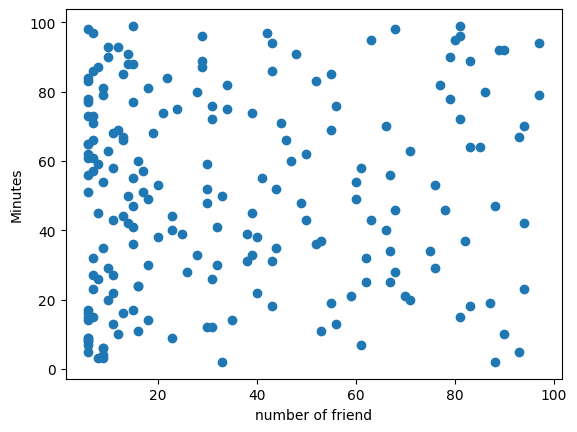

In [103]:
plt.scatter(num_friends, daily_minutes)

plt.xlabel("number of friend")
plt.ylabel("Minutes")
plt.show()

## **Simpson’s Paradox**

**Simpson’s Paradox** is one of the most counterintuitive phenomena in statistics. It occurs when a trend that appears in several different groups of data disappears—or even reverses—when those groups are combined.

In simpler terms: **The data can tell you two completely different stories depending on whether you look at the sub-groups or the overall combined set.**

- **A Classic Example**
    - Imagine you are a Data Scientist analyzing the effectiveness of two medical treatments, **Treatment A** and **Treatment B**, based on recovery rates.

| Group | Treatment A | Treatment B |
| :--- | :--- | :--- |
| **Small Kidney Stones** | 93% (81/87) | 87% (234/270) |
| **Large Kidney Stones** | 73% (192/263) | 69% (55/80) |
| **Total Combined** | **78%** (273/350) | **83%** (289/350) |

* **Look at the groups:** Treatment A performs better for *both* small and large kidney stones.
* **Look at the total:** Treatment B appears to be the better overall treatment (83% vs 78%).

- **How is this possible?**
    - It happens because of a **confounding variable** (in this case, the severity of the stone). Treatment B was used more often on patients with small stones (who are easier to cure), while Treatment A was used more often on patients with large stones (who are harder to cure). The "total" column is misleading because it mixes two different populations that aren't comparable.

---

- **Why Data Scientists Must Care**
    - Simpson’s Paradox is a constant trap in professional data analysis. If you rely only on aggregated data (the "total"), you will often reach the wrong conclusion.

1.  **The Hidden Variable:** The paradox usually happens when there is an unobserved or ignored variable that influences both the group assignment and the result.
2.  **Model Bias:** If you build a machine learning model on combined data that suffers from Simpson’s Paradox, your model will be fundamentally flawed. It will learn a "shortcut" (the paradox) rather than the actual underlying causal relationship.
3.  **Visualization Matters:** Always perform **stratified analysis**. Break your data down by categories (like location, time, or customer type) to ensure that the trend you see in the aggregate is truly representative of the individual segments.

---

- **How to avoid the trap:**
    * **Segment your data:** Always look at your metrics at lower granular levels before aggregating.
    * **Identify Confounders:** Ask yourself, "Is there an underlying factor that might be influencing how these groups were formed?"
    * **Causal Inference:** Remember that statistics describes what *is*, but it doesn't always explain *why*.

## **Some Other Correlational Caveats**

This chapter is teaching you a critical lesson: **Correlation is not a "catch-all" for every kind of relationship.** It is a specialized tool that only looks for one specific pattern.

Here is the breakdown of the two main limitations of correlation.

---

- **1. Correlation Only Measures "Linear" Relationships**
    - Correlation looks for a "straight-line" pattern. It asks: *"If X increases, does Y increase or decrease at a constant rate?"* If the data follows a different shape, correlation will be blind to it.

**Example: The V-Shape ($y = |x|$)**
- Look at the data you provided:
    * $x = [-2, -1, 0, 1, 2]$
    * $y = [2, 1, 0, 1, 2]$

If you plot this, you get a perfect "V" shape. 

* **Why correlation is 0:** Correlation calculates how $x_i$ and $y_i$ move away from their *means*. 
    * For the first half ($x = -2, -1$), as $x$ increases, $y$ *decreases*. This looks like a negative relationship.
    * For the second half ($x = 1, 2$), as $x$ increases, $y$ *increases*. This looks like a positive relationship.
* **The Result:** The "negative" and "positive" parts cancel each other out exactly, leaving you with a correlation of **0**. The math says "no relationship," but your eyes clearly see a perfect "V."

**Key Takeaway:** Always plot your data (using a scatter plot) before trusting a correlation number. A correlation of 0 doesn't mean "no relationship"; it means "no linear relationship."

---

- **2. Correlation Measures "Direction," Not "Importance"**
    - Correlation tells you how well the points fit on a line, but it ignores the **scale** or the **real-world significance** of the change.

**Example: The Near-Flat Line**
Look at your second set:
* $x = [-2, -1, 0, 1, 2]$
* $y = [99.98, 99.99, 100, 100.01, 100.02]$

If you calculate the correlation, it will be **+1 (perfect correlation)**. Every single time $x$ moves up, $y$ moves up by exactly 0.01.

* **Why it's misleading:** If you are measuring something like "Global Sea Levels in Millimeters" vs. "Time," a change of 0.01 over several years might be statistically perfect, but practically meaningless. 
* **The Trap:** A "perfect" correlation can describe a relationship that is so tiny it’s essentially noise. Conversely, a weak correlation (like 0.3) might represent a massive, life-changing trend in a complex system like stock markets or human behavior.

---

- **Summary for your Data Science work:**

| Correlation Says | What it actually means |
| :--- | :--- |
| **0** | No **straight-line** relationship. (Could be a V-shape, a circle, or totally random.) |
| **+1 / -1** | The data fits a **straight line** perfectly. (Doesn't mean the relationship is large or important.) |

When you are doing your Exploratory Data Analysis (EDA), remember: **Correlation is a filter, not a final answer.** It helps you find leads, but you have to use plots and domain knowledge to confirm if those leads are actually interesting or useful.

## **Correlation and Causation**

The relationship between correlation and causation is one of the most important concepts for a data scientist to master. The mantra **"correlation does not imply causation"** is a reminder that seeing two things happen together does not mean one is the direct cause of the other.

- **The Definitions**
    * **Correlation:** A statistical measure (like the Pearson coefficient) that tells you how two variables move in relation to one another.
    * **Causation:** A cause-and-effect relationship where a change in one variable is directly responsible for a change in another.

---

- **Why Correlation Is Often Mistaken for Causation**
    - It is easy to assume causation when you see a strong correlation, but there are usually three other possibilities:
        1.  **The Confounding Variable (The "Third" Factor):** This is the most common trap. Two variables appear related because they are both influenced by a hidden  third variable.
            * *Example:* Ice cream sales and forest fires are highly correlated. The hidden variable is **hot, dry weather**, which causes more people to buy ice cream and also creates conditions ripe for fires.
        2.  **Reverse Causality:** You might think $A$ causes $B$, when in reality, $B$ causes $A$.
            * *Example:* High levels of stress are correlated with high blood pressure. Is the stress causing the high blood pressure, or is the physical strain of having high blood pressure causing the person to feel stressed?
        3.  **Coincidence (Spurious Correlation):** Sometimes, two variables move together purely by chance. This is more common when you have "Big Data" and are mining for patterns without a theoretical basis.
            * *Example:* The number of people who drowned by falling into a pool correlates almost perfectly with the number of films Nicolas Cage appeared in that year. This is a purely random, non-causal statistical quirk.

---

- **How Data Scientists Move from Correlation to Causation**
    - Since correlation doesn't prove causation, how do we find the truth? 

* **Controlled Experiments (A/B Testing):** This is the gold standard. By randomly assigning subjects to different groups, you keep all other factors constant and change only one variable. This allows you to isolate the effect.
* **Causal Inference Models:** When you cannot run an experiment (e.g., you can't force people to smoke to see if it causes cancer), you use statistical techniques like **Instrumental Variables** or **Propensity Score Matching** to mathematically control for confounding variables.
* **Domain Knowledge:** Always ask, "Does this relationship make sense?" Statistics can find patterns, but your knowledge of the field (e.g., finance, medicine, engineering) must determine if those patterns are plausible.

---

- **Why This Matters for Your Projects**
If you build a predictive model based on correlation alone, your model will work perfectly as long as the "hidden" third variable stays constant. But if the environment changes, your model will fail because it was learning a **correlation** (a symptom) rather than a **causal mechanism** (the underlying law).

## **For Further Exploration**

- Statistics is important. (Or maybe statistics are important?) If you want to be a better data scientist, it would be a good idea to read a statistics textbook. Many are freely available online, including:
    - **Introductory Statistics**, by Douglas Shafer and Zhiyi Zhang (Saylor Foundation)
    - **OnlineStatBook**, by David Lane (Rice University)
    - **Introductory Statistics**, by OpenStax (OpenStax College)